# NIH Chest XRay - Exploratory Data Analysis
## Objective:
- Explore and describe the dataset (size, classes, missing values, imbalance, correalation)

## Contents:

1. Dataset Overview (size, structure, missing values)
2. Label Distribution (class imbalance)
3. Patient Demographics (age, gender)
4. Image Properties (samples, resolution, pixel intensity)
5. Multi-label Analysis (labels per image, co-occurrence)
6. Dataset Quality Checks (split integrity, patient leakage checks)
7. Visual Inspection (sample X-ray images)
8. Key Findings Summary

## 1. Dataset Overview

This section provides a general overview of the dataset, including its structure, feature types, statistical properties, and missing values.

In [1]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Set dataset paths
dataset_path = '/Volumes/PM961/archive-chest-xrays-nih'
csv_path = os.path.join(dataset_path, "Data_Entry_2017.csv")

In [2]:
# Load the dataset
df = pd.read_csv(csv_path)
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [3]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  str    
 1   Finding Labels               112120 non-null  str    
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  str    
 6   View Position                112120 non-null  str    
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), str(4)
memory usage: 10.3 MB


In [4]:
# Statistical summary of numerical columns
df.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,0.0
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649,NaN
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174,NaN
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000,NaN
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000,NaN
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000,NaN
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000,NaN
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800,NaN


In [5]:
# Check missing values
df.isnull().sum()

Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64

## 2. Label Distribution

This section analyzes the distribution of labels in the dataset in order to identify class imbalance and the prevalence of different pathologies.

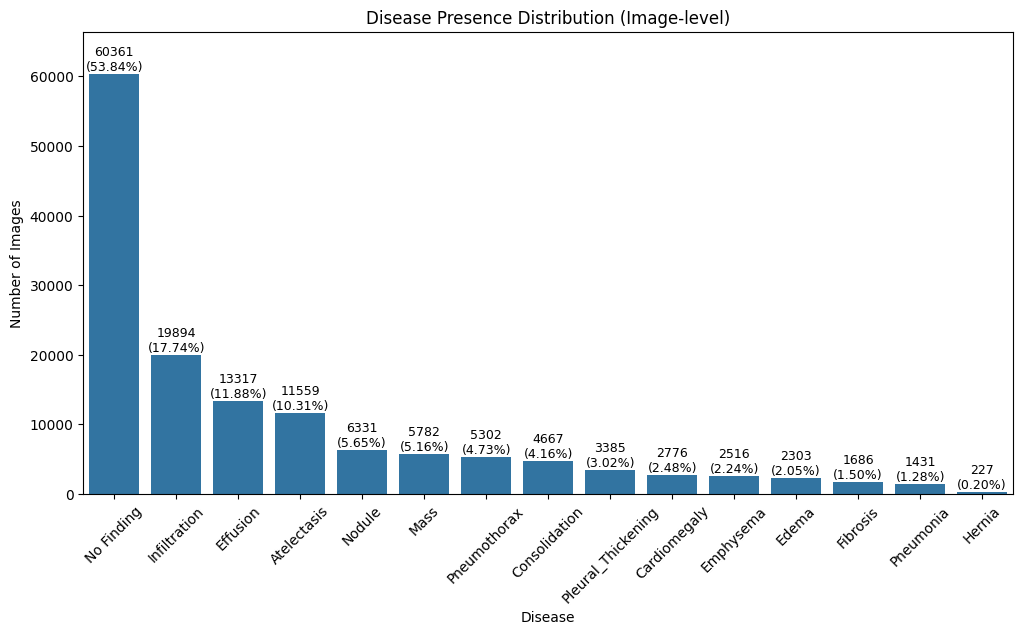

In [ ]:
# Count images containing each disease
label_counts = df["Finding Labels"].str.get_dummies(sep="|").sum().sort_values(ascending=False)

# Create a plot
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=label_counts.index,
    y=label_counts.values
)

total = len(df)

# Add percentage and count labels above bars
for i, count in enumerate(label_counts.values):
    percent = (count / total) * 100
    ax.text(
        i,
        count + 500,
        f"{count}\n({percent:.2f}%)",
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=45)
plt.title("Disease Presence Distribution (Image-level)")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.ylim(0, label_counts.max() * 1.10)
os.makedirs("..outputs/eda", exist_ok=True)
plt.savefig("..outputs/eda/disease_presence_distribution.png", bbox_inches="tight")
plt.show()

## 3. Patient Demographics

This section examines the demographic characteristics of patients (gender and age).

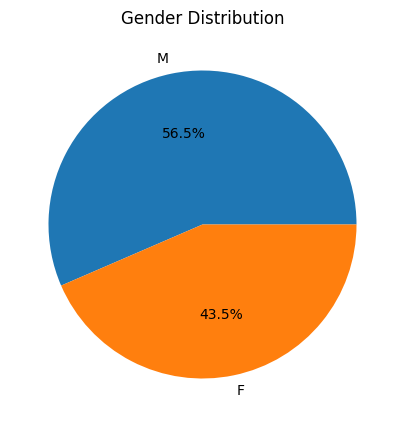

In [7]:
# Gender distribution
gender_counts = df["Patient Gender"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)
plt.title("Gender Distribution")
plt.show()

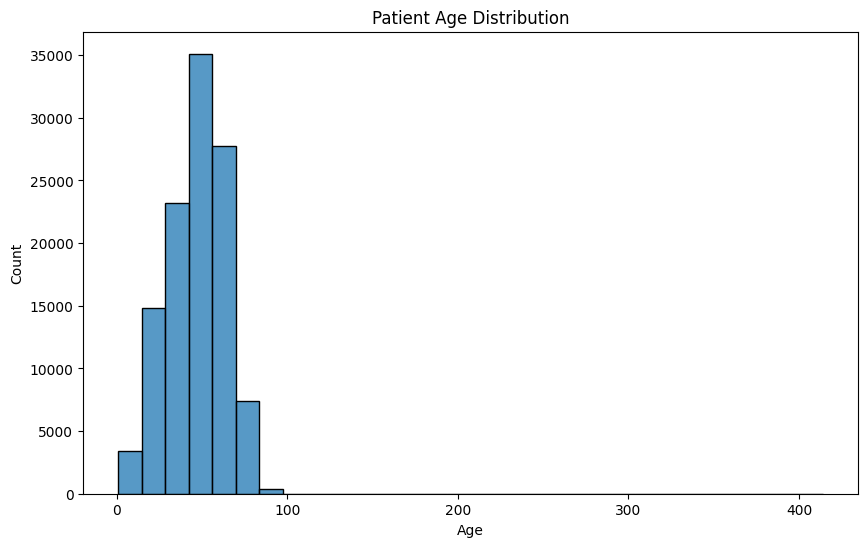

In [8]:
# Age distribution
plt.figure(figsize=(10,6))
sns.histplot(df["Patient Age"], bins=30)
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## 4. Image Properties

This section explores sample X-ray images and their basic properties, including resolution statistics.

In [9]:
# Build an index of all image folders
image_root = dataset_path
image_dirs = [
    os.path.join(image_root, d)
    for d in os.listdir(image_root)
    if d.startswith("images_")
]

# Create a lookup dictionary (image_name → full path)
image_path_map = {}

for folder in image_dirs:
    img_folder = os.path.join(folder, "images")
    
    if os.path.exists(img_folder):
        for img_name in os.listdir(img_folder):
            image_path_map[img_name] = os.path.join(img_folder, img_name)

In [10]:
# Compute image size statistics (random 5000 images)
widths = []
heights = []

sample_df = df.sample(5000, random_state=42)

for img_name in sample_df["Image Index"]:
    if img_name in image_path_map:
        img = Image.open(image_path_map[img_name])
        
        widths.append(img.size[0])
        heights.append(img.size[1])

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Average width: 1024.0
Average height: 1024.0


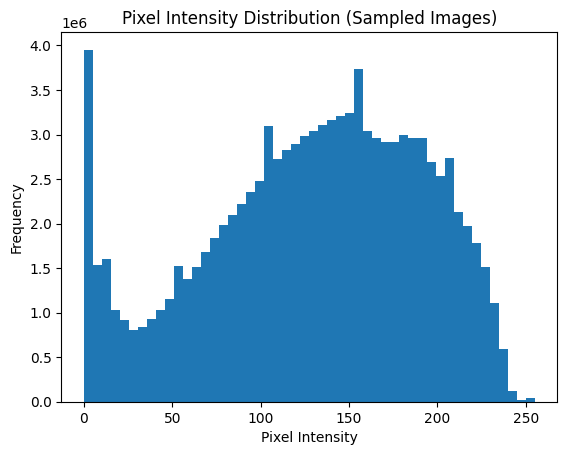

In [11]:
# Pixel intensity distribution (sample of images)
sample_df = df.sample(100, random_state=42)
all_pixels = []
for img_name in sample_df["Image Index"]:
    if img_name in image_path_map:
        img = np.array(Image.open(image_path_map[img_name]).convert("L"))
        all_pixels.extend(img.ravel())

plt.hist(all_pixels, bins=50)
plt.title("Pixel Intensity Distribution (Sampled Images)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

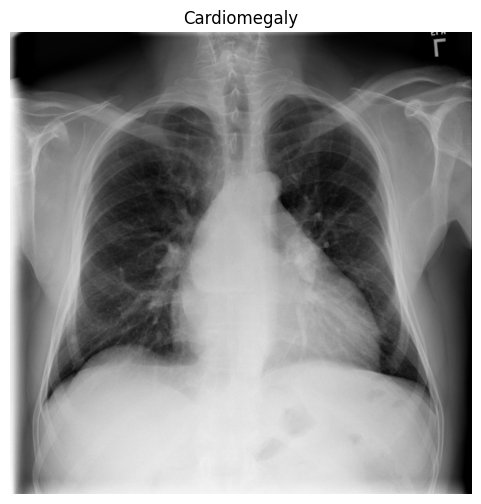

In [12]:
# Display a sample image
sample_image_name = df.iloc[0]["Image Index"]

if sample_image_name in image_path_map:
    img = Image.open(image_path_map[sample_image_name])

    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap="gray")
    plt.title(df.iloc[0]["Finding Labels"])
    plt.axis("off")
    plt.show()
else:
    print("Image not found:", sample_image_name)

## 5. Multi-label Analysis

This section analyzes the multi-label structure of the dataset, including the number of labels per image and disease co-occurrence patterns.

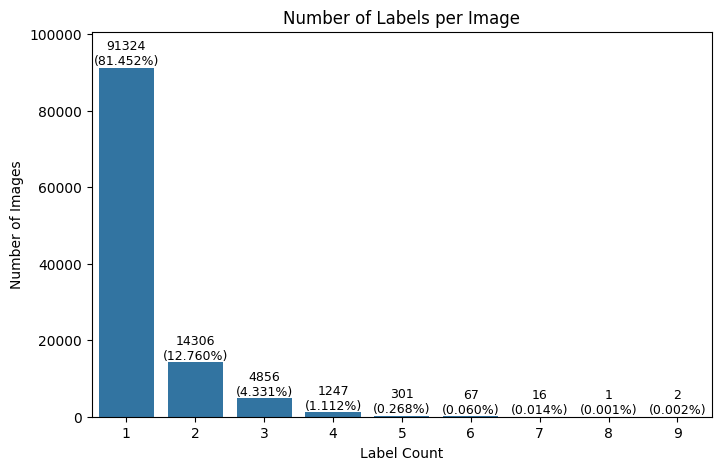

In [ ]:
# Number of labels per image
df["label_count"] = df["Finding Labels"].apply(lambda x: len(x.split("|")))

plt.figure(figsize=(8,5))
ax = sns.countplot(x="label_count", data=df)

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percent = (count / total) * 100
    
    ax.text(
        p.get_x() + p.get_width() / 2,
        count,
        f"{count}\n({percent:.3f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Number of Labels per Image")
plt.xlabel("Label Count")
plt.ylabel("Number of Images")
plt.ylim(0, ax.get_ylim()[1] * 1.05)
os.makedirs("..outputs/eda", exist_ok=True)
plt.savefig("..outputs/eda/number_of_labels_per_image.png", bbox_inches="tight")
plt.show()

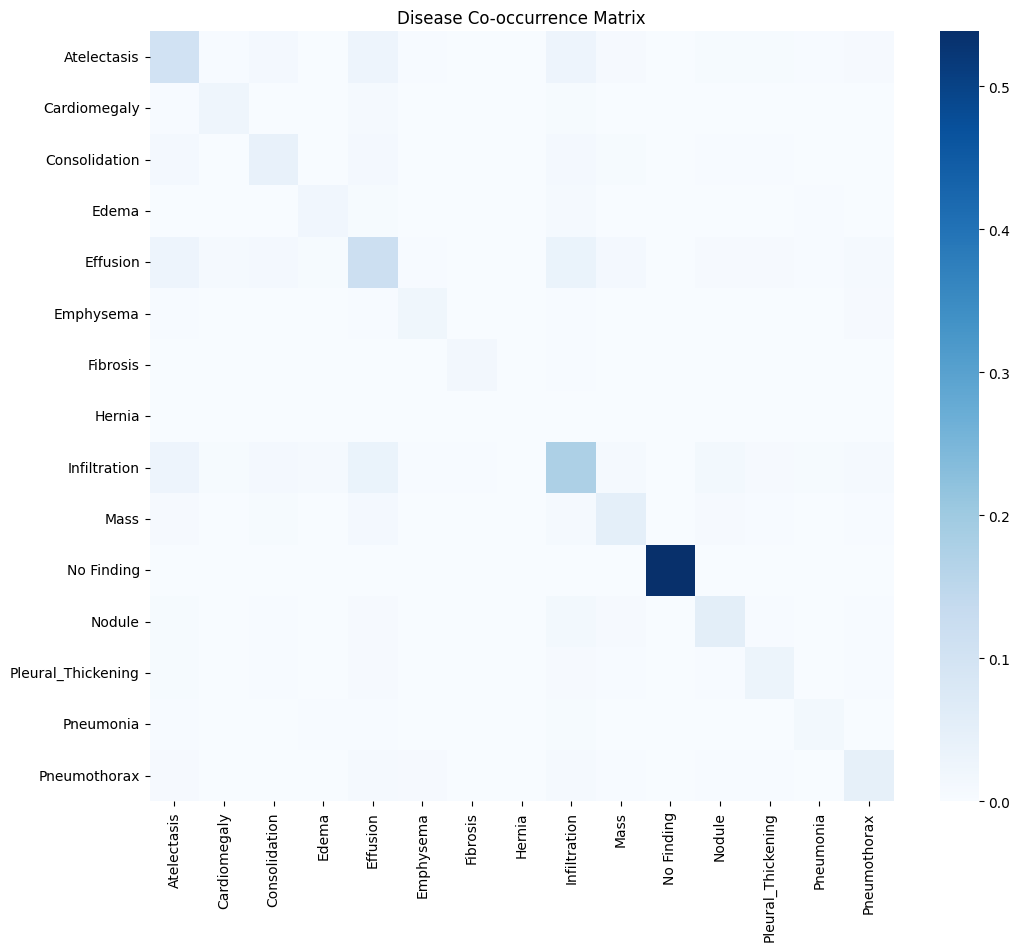

In [14]:
from sklearn.preprocessing import MultiLabelBinarizer

# Convert labels into multi-hot encoding
labels = df["Finding Labels"].apply(lambda x: x.split("|"))

mlb = MultiLabelBinarizer()
label_matrix = mlb.fit_transform(labels)

label_df = pd.DataFrame(label_matrix, columns=mlb.classes_)

# Compute co-occurrence matrix
co_matrix = label_df.T.dot(label_df)
co_matrix_norm = co_matrix / len(label_df)

plt.figure(figsize=(12,10))
sns.heatmap(co_matrix_norm, cmap="Blues")
plt.title("Disease Co-occurrence Matrix")
plt.show()

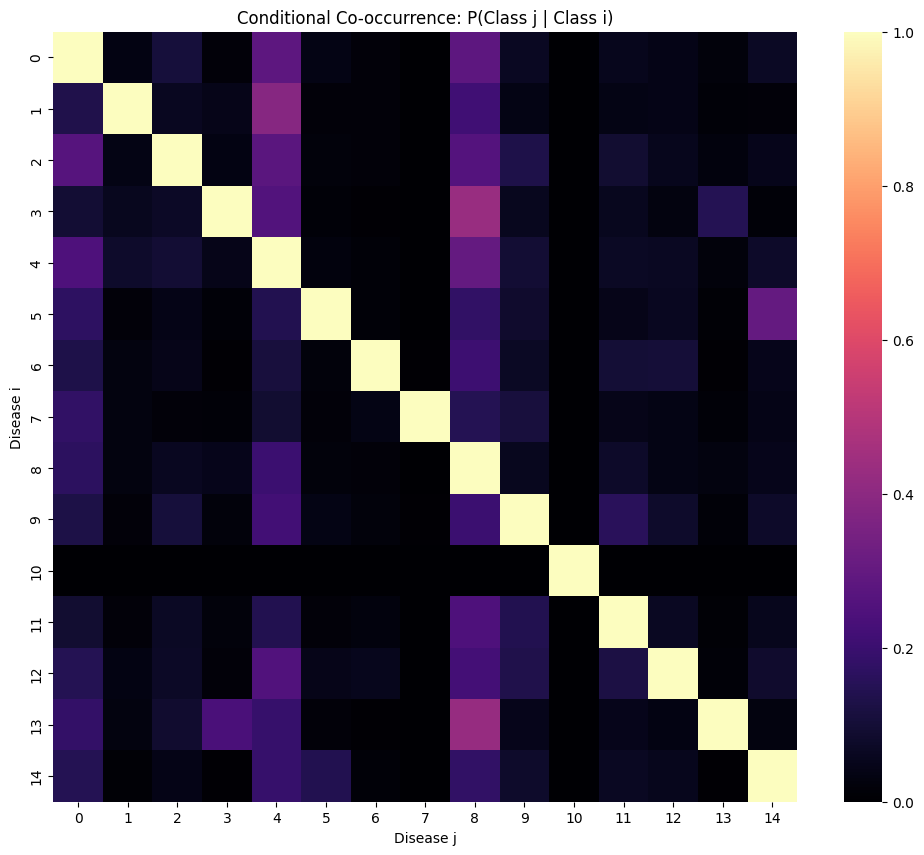

In [ ]:
# Convert to numpy matrix
Y = label_df.to_numpy()

# Co-occurrence counts
co_counts = Y.T @ Y

# Conditional probability P(j | i)
support = Y.sum(axis=0)
support_safe = np.where(support == 0, 1, support)

cond_matrix = co_counts / support_safe[:, None]

plt.figure(figsize=(12,10))
sns.heatmap(cond_matrix, cmap="magma", vmin=0, vmax=1)
plt.title("Conditional Co-occurrence: P(Class j | Class i)")
plt.xlabel("Disease j")
plt.ylabel("Disease i")
os.makedirs("..outputs/eda", exist_ok=True)
plt.savefig("..outputs/eda/cooccurrence_matrix_conditional.png", bbox_inches="tight")
plt.show()

## 6. Dataset Quality Checks

This section validates the correctness of dataset splits and checks for potential data leakage at both file and patient levels.

In [16]:
# Patient uniqueness check
unique_patients = df["Patient ID"].nunique()
total_images = len(df)

print("Unique patients:", unique_patients)
print("Total images:", total_images)

Unique patients: 30805
Total images: 112120


In [17]:
# Split integrity and patient leakage check

# Load split files
with open(os.path.join(dataset_path, "train_val_list.txt"), "r") as f:
    train_files = set(f.read().splitlines())

with open(os.path.join(dataset_path, "test_list.txt"), "r") as f:
    test_files = set(f.read().splitlines())

# File-level split integrity check
file_overlap = train_files.intersection(test_files)

# Create split dataframes
train_df = df[df["Image Index"].isin(train_files)].copy()
test_df = df[df["Image Index"].isin(test_files)].copy()

print("Train images:", len(train_files))
print("Train samples in df:", len(train_df))
print("Test images:", len(test_files))
print("Test samples in df:", len(test_df))
print("File overlap:", len(file_overlap))

# Patient-level leakage check
train_patients = set(train_df["Patient ID"].unique())
test_patients = set(test_df["Patient ID"].unique())
patient_overlap = train_patients.intersection(test_patients)

print("\nTrain patients:", len(train_patients))
print("Test patients:", len(test_patients))
print("Patient overlap:", len(patient_overlap))

Train images: 86524
Train samples in df: 86524
Test images: 25596
Test samples in df: 25596
File overlap: 0

Train patients: 28008
Test patients: 2797
Patient overlap: 0


## 7. Visual Inspection

This section provides a visual inspection of randomly selected chest X-ray images to assess variability in image quality, anatomical structures, and disease presentations.

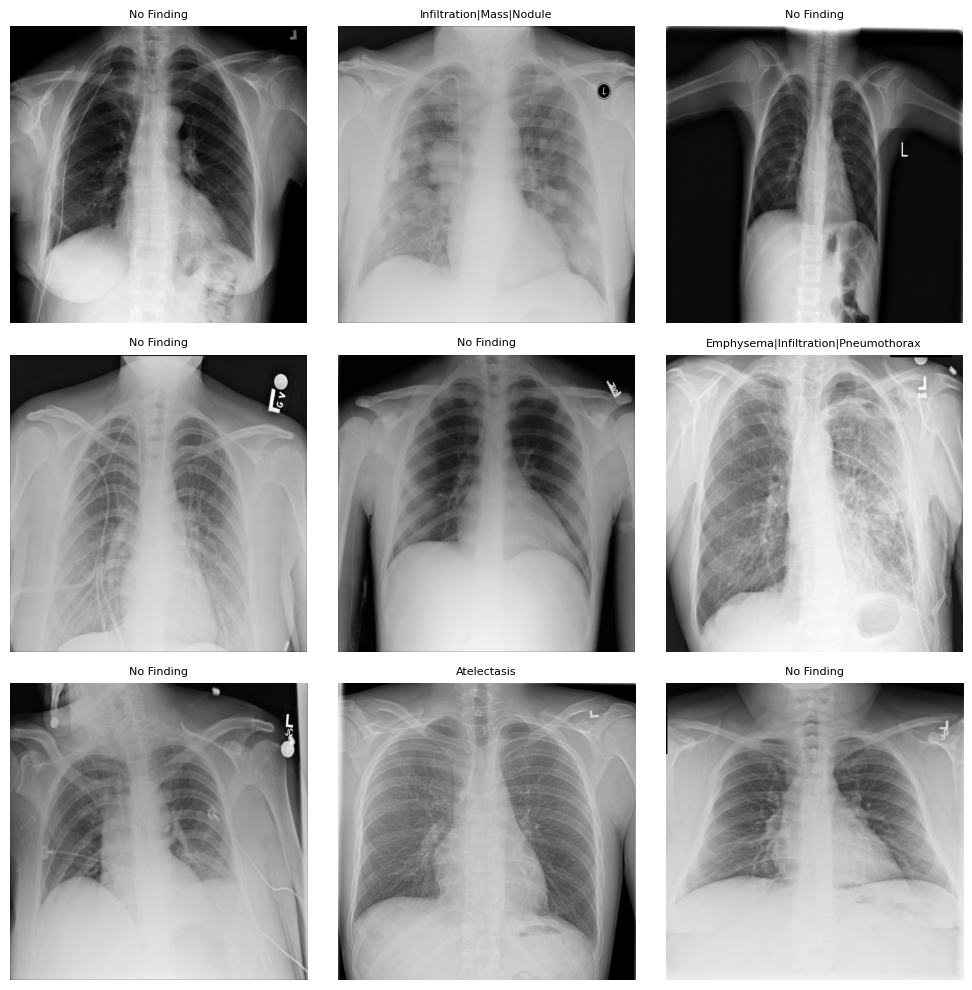

In [18]:
# Visual inspection of random samples
fig, axes = plt.subplots(3, 3, figsize=(10,10))
sample_df = df.sample(9, random_state=42).reset_index(drop=True)

for i, ax in enumerate(axes.flat):
    img_name = sample_df.iloc[i]["Image Index"]

    if img_name in image_path_map:
        img = Image.open(image_path_map[img_name])
        ax.imshow(img, cmap="gray")
        ax.set_title(sample_df.iloc[i]["Finding Labels"], fontsize=8)
    else:
        ax.set_title("Missing image", fontsize=8)

    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Key Findings from EDA

- The dataset contains *112,120 images* with *15 unique labels*.
- Most images contain 1–2 labels, confirming *multi-label structure*.
- The dataset is highly imbalanced, with the dominant class being *No Findings (53.84%)*, while *Hernia (0.20%)*, *Pneumonia (1.28%)*, and *Fibrosis (1.50%)* are extremely rare. These classes are strong candidates for class weighting and per-class threshold tuning.
- Significant *co-occurrence* exists between certain diseases. Strong conditional relationships include Edema -> Infiltration, Pneumonia -> Infiltration, Cardiomegaly -> Effusion, and Emphysema -> Pneumothorax. These dependencies should be considered when interpreting per-class errors and setting class-specific thresholds.
- Image resolution varies but is generally consistent.
- No major missing data was found in key columns.
- Train/test filename overlap is zero and patient overlap is zero, which is the expected outcome for clean split integrity.

These findings justify the need for:
- A multi-label classification approach (sigmoid output layer)
- Class imbalance handling techniques
- Standardized preprocessing of images prior to model training